Index(['inflation', 'unemployment', 'interest_rate', 'rental_housing',
       'job_opening', 'economy', 'tourism', 'layoff', 'employment',
       'debt_management', 'rent', 'wages', 'real_estate', 'used_car',
       'gas_price', 'recession', 'bankruptcy', 'mortgage_rate',
       'housing_market', 'tax_cut', 'federal_reserve'],
      dtype='object')


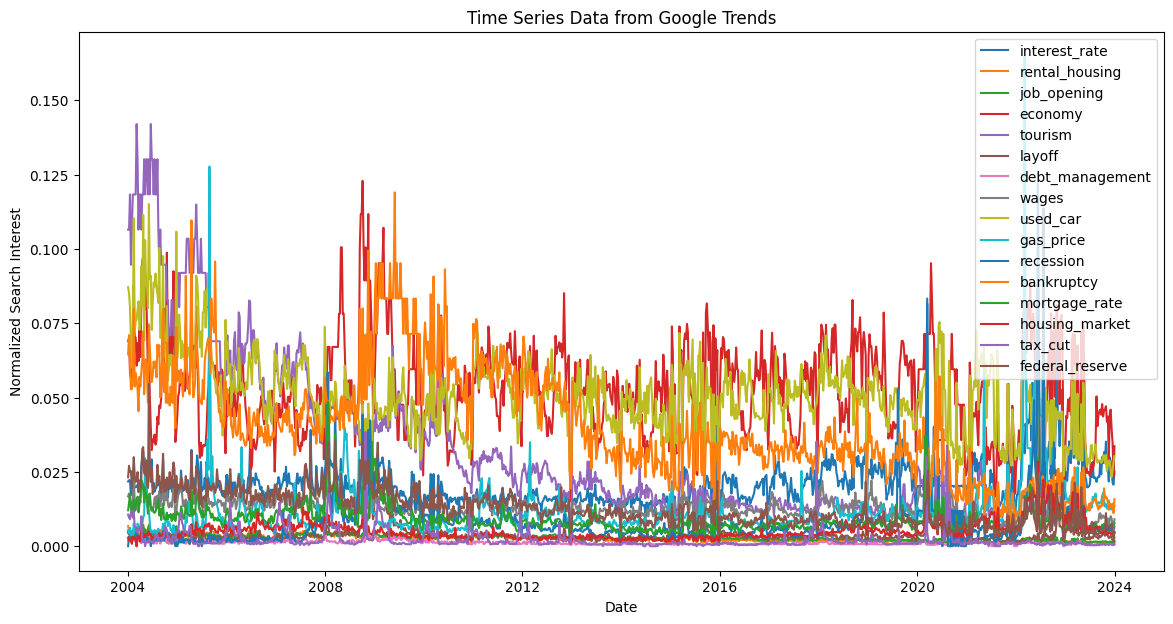

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('gt_data.csv', parse_dates=["start"], index_col="start")
#print col names
print(df.columns)

# Plotting all the series can be overwhelming; let's plot a few for clarity
plt.figure(figsize=(14, 7))
for col in df.columns:
    if col in ['inflation','unemployment','real_estate','rent','employment']:
        continue
    plt.plot(df.index, df[col], label=col)


# Add titles and labels
plt.title('Time Series Data from Google Trends')
plt.xlabel('Date')
plt.ylabel('Normalized Search Interest')
plt.legend()

# Display the plot
plt.show()

In [2]:
df2 = pd.read_csv('questionsdata.csv')
# Convert 'Date' column to datetime format
df2['Date'] = pd.to_datetime(df2['Month'].astype(str) + ' ' + df2['Year'].astype(str))
df2.to_csv('questionsdata.csv', index=True)

/var/folders/92/vlqhq91x3kv5qxmxwcj6pjrw0000gn/T/ipykernel_20768/648176417.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2['Date'] = pd.to_datetime(df2['Month'].astype(str) + ' ' + df2['Year'].astype(str))


Index(['Month', 'Year', 'Personal Finance Current',
       'Personal Finance Expected', 'Business Condition 12 Months',
       'Business Condition 5 Years', 'Buying Conditions', 'Current Index',
       'Expected Index', 'Unnamed: 9', 'Date'],
      dtype='object')


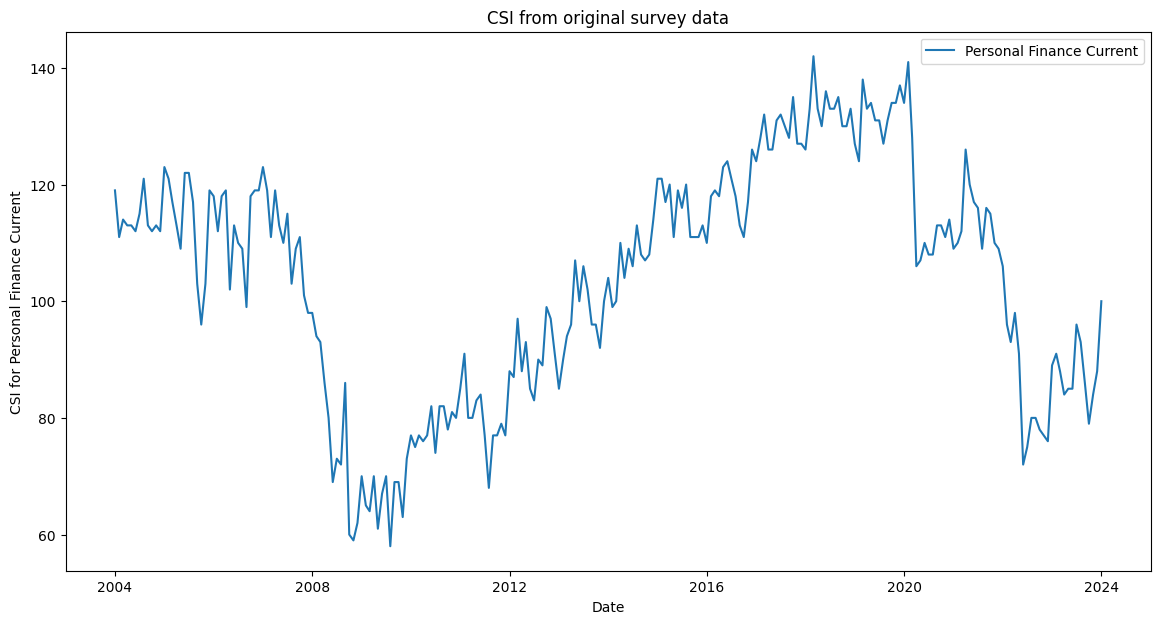

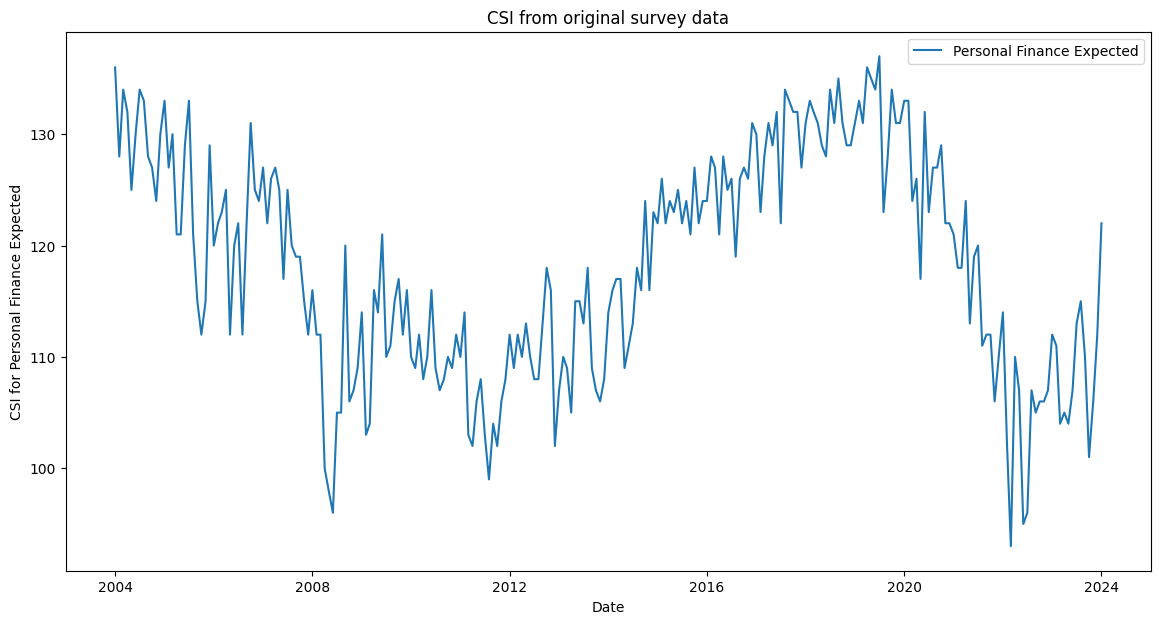

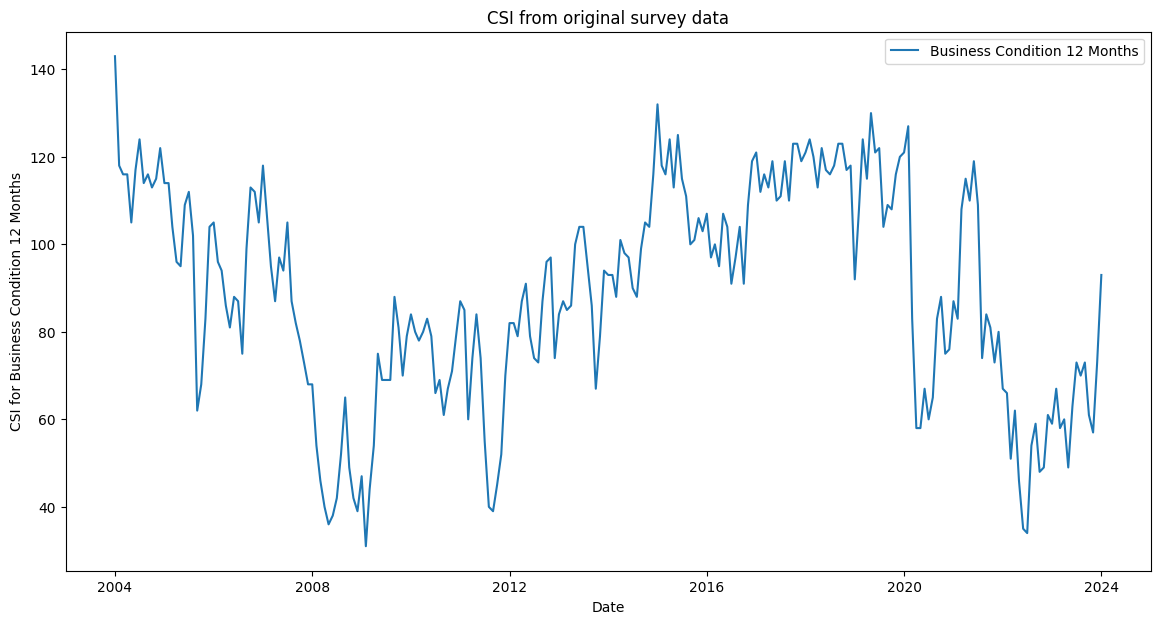

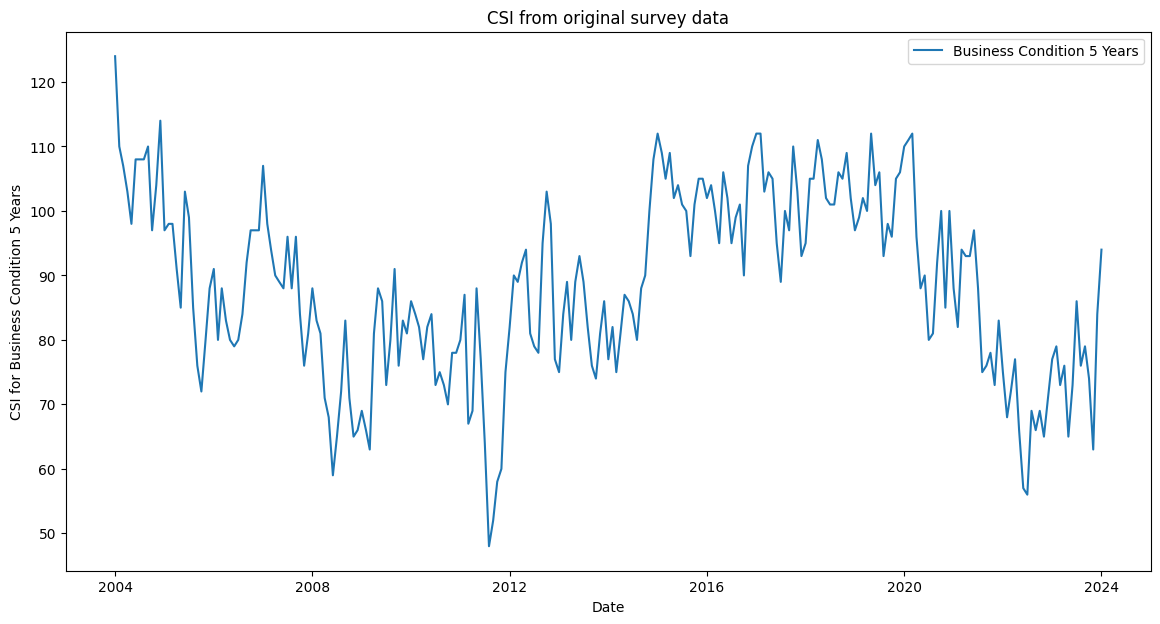

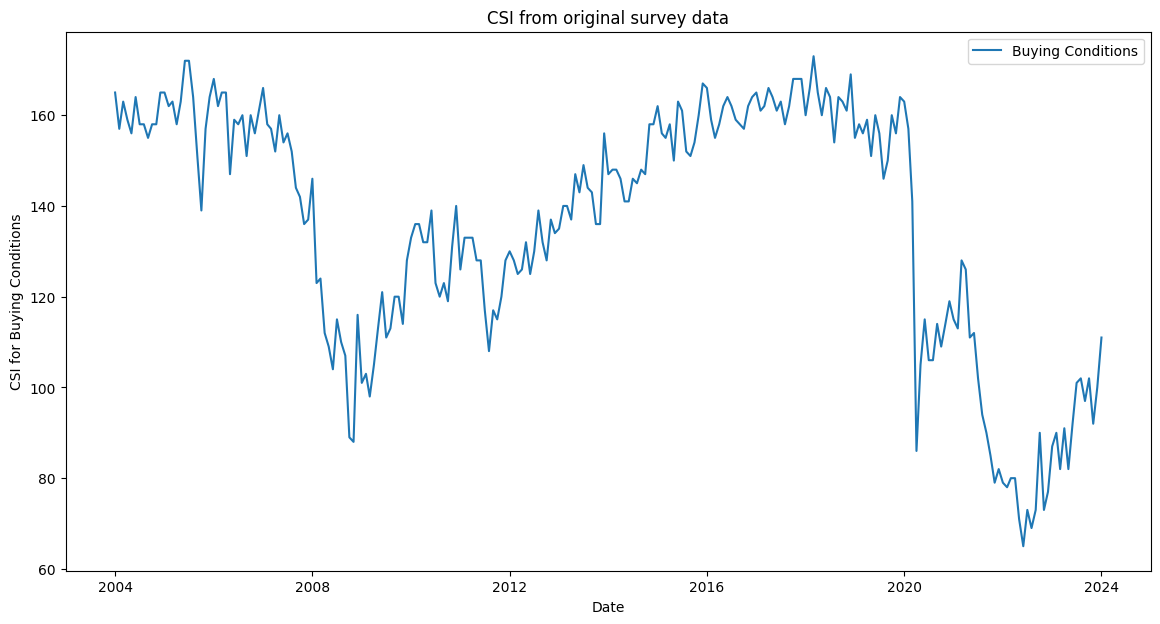

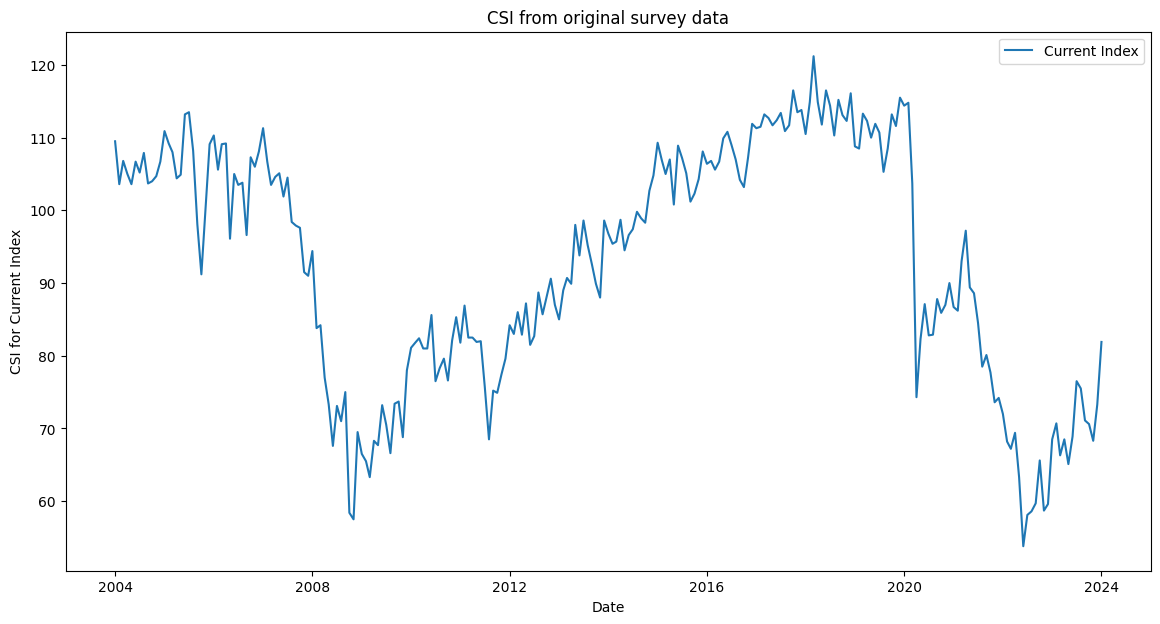

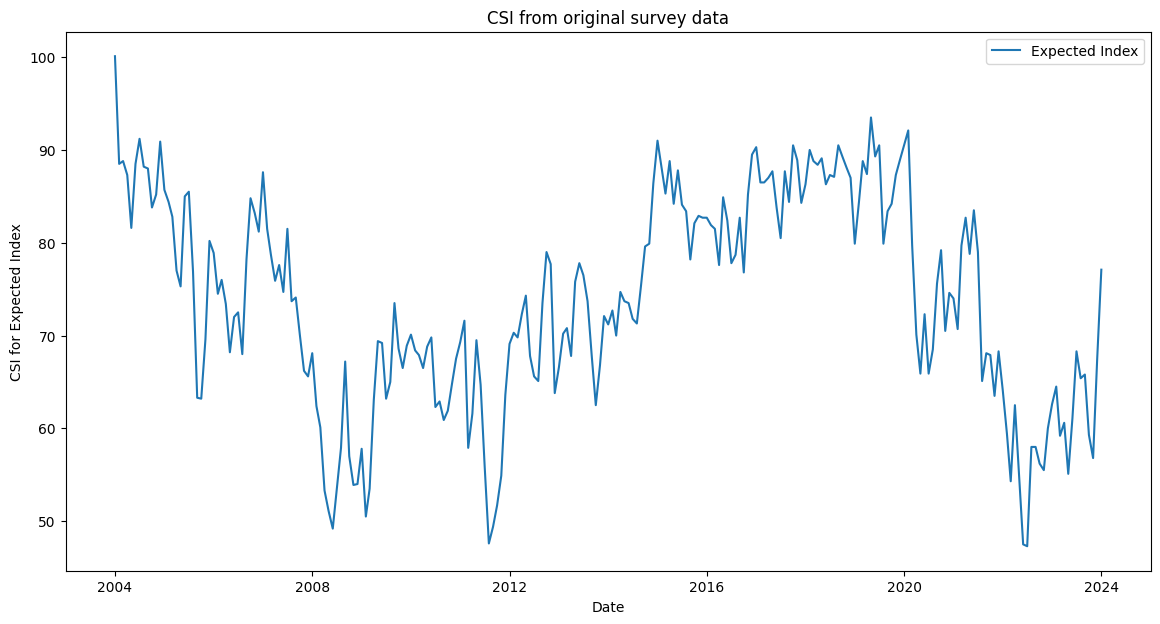

In [3]:


# Group by Year and aggregate the data (assuming 'Month' is a categorical column)
print(df2.columns)
#groupby year and month

for col in df2.columns:
    #only label year on x axis also skip first two columns and last column
    if col in ['Month','Year','Unnamed: 9','Date']:
        continue
    plt.figure(figsize=(14, 7))
    plt.plot(df2['Date'], df2[col], label=col)
    # Add titles and labels
    plt.title('CSI from original survey data')
    plt.xlabel('Date')
    plt.ylabel(f'CSI for {col}')
    plt.legend()


    # Display the plot
    plt.show()

In [ ]:
import numpy as np
import scipy as sp
from statsmodels.tsa.api import VAR
#fit regression model
model = VAR(df2)
results = model.fit()



